In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from typing import Callable, List, Dict
import warnings
warnings.filterwarnings("ignore")
HERE = Path.cwd().resolve().parent
DATASETS = HERE.parent/'datasets'
# %load_ext google.colab.data_table

In [19]:
from matplotlib import rcParams

# Set global font sizes
rcParams.update({
    'axes.titlesize': 16,       # Title font size
    'axes.labelsize': 14,       # X and Y label font size
    'axes.labelweight': 'bold',
    'xtick.labelsize': 12,      # X tick label font size
    'ytick.labelsize': 12,      # Y tick label font size
    'legend.fontsize': 12,      # Legend font size
    'font.size': 12             # Default font size
})


In [20]:
data_folder = DATASETS / "processed"

In [21]:
raw_dataset: pd.DataFrame = pd.read_csv(data_folder/'cleaned_dataset_filtered_by_carbon_number_dropped_tests.csv')
# cleaned_dataset_filtered_by_carbon_number_dropped_tests.csv

In [22]:
raw_dataset

,location,carbon number,electrode,voltage,absJ,log_absJ,J,current,time,date,...,delay,autozero time,number of V(high) to V(low) spans,Junction diameter,Magnification,scan V direction,spot ID,scan ID,path,substrate ID
0,"Ames, Iowa",10,Ag,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...","[9.624195e-07, 0.0001100908, 0.0002446355, 0.0...","[-6.016635586149714, -3.9582489723649963, -3.6...","[9.624195e-07, 0.0001100908, 0.0002446355, 0.0...","[1.209412e-11, 1.383442e-09, 3.074181e-09, 5.1...","[0.0, 0.5761719, 0.7636719, 0.9521484, 1.13964...","February 20, 2017",...,2.0,0.5,1.0,0.5,0.5,1.0,1.0,0.0,"Ames, Iowa\Ag\C10\sub1\1 2-11_data.txt",sub1
1,"Ames, Iowa",10,Ag,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...","[7.174183e-07, 7.705028e-06, 0.0001912089, 0.0...","[-6.1442275494782095, -5.113225778720591, -3.7...","[7.174183e-07, 7.705028e-06, 0.0001912089, 0.0...","[9.015344e-12, 9.682424e-11, 2.402802e-09, 4.1...","[12.19238, 12.71582, 13.29199, 13.47949, 13.66...","February 20, 2017",...,2.0,0.5,1.0,0.5,0.5,1.0,1.0,1.0,"Ames, Iowa\Ag\C10\sub1\1 2-11_data.txt",sub1
2,"Ames, Iowa",10,Ag,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...","[1.322095e-07, 8.359645e-05, 0.0001881367, 0.0...","[-6.878737337215404, -4.077812164883306, -3.72...","[1.322095e-07, 8.359645e-05, 0.0001881367, 0.0...","[1.661393e-12, 1.050504e-09, 2.364196e-09, 4.1...","[25.21875, 25.79492, 25.9834, 26.1709, 26.3593...","February 20, 2017",...,2.0,0.5,1.0,0.5,0.5,1.0,1.0,2.0,"Ames, Iowa\Ag\C10\sub1\1 2-11_data.txt",sub1
3,"Ames, Iowa",10,Ag,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...","[7.638213e-07, 7.671647e-06, 0.0001870659, 0.0...","[-6.117008235012866, -5.115111388824767, -3.72...","[7.638213e-07, 7.671647e-06, 0.0001870659, 0.0...","[9.598461e-12, 9.640476e-11, 2.350739e-09, 4.1...","[37.41211, 37.93555, 38.51172, 38.7002, 38.887...","February 20, 2017",...,2.0,0.5,1.0,0.5,0.5,1.0,1.0,3.0,"Ames, Iowa\Ag\C10\sub1\1 2-11_data.txt",sub1
4,"Ames, Iowa",10,Ag,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...","[7.890647e-07, 7.66101e-06, 0.0001846145, 0.00...","[-6.102887385002299, -5.115713970770625, -3.73...","[7.890647e-07, 7.66101e-06, 0.0001846145, 0.00...","[9.915679e-12, 9.627109e-11, 2.319934e-09, 4.1...","[50.08203, 50.60547, 51.18164, 51.37012, 51.55...","February 20, 2017",...,2.0,0.5,1.0,0.5,0.5,1.0,1.0,4.0,"Ames, Iowa\Ag\C10\sub1\1 2-11_data.txt",sub1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13033,"Boston, Massachusetts",9,Au,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...","[1.177058e-06, 0.0002408695, 0.0005211176, 0.0...","[-5.929202136596379, -3.618218188877938, -3.28...","[1.177058e-06, 0.0002408695, 0.0005211176, 0.0...","[3.936462e-12, 8.055451e-10, 1.742785e-09, 2.9...","[0.0, 0.6728516, 1.344727, 1.462891, 1.581055,...","December 21, 2011",...,2.0,0.5,1.0,0.5,0.5,1.0,9.0,0.0,"Boston, Massachusetts\Au\C9SH - pur\12202011\9...",12202011
13034,"Boston, Massachusetts",9,Au,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...","[1.631114e-06, 0.0001892274, 0.0002779464, 0.0...","[-5.787515684673542, -3.7230159778325844, -3.5...","[1.631114e-06, 0.0001892274, 0.0002779464, 0.0...","[5.45497e-12, 6.328374e-10, 9.295422e-10, 2.24...","[10.7998, 11.64355, 11.91504, 12.58789, 12.706...","December 21, 2011",...,2.0,0.5,1.0,0.5,0.5,1.0,9.0,1.0,"Boston, Massachusetts\Au\C9SH - pur\12202011\9...",12202011
13035,"Boston, Massachusetts",9,Au,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...","[1.589646e-06, 0.0002012291, 0.0002787079, 0.0...","[-5.79869957842396, -3.6963092151887604, -3.55...","[1.589646e-06, 0.0002012291, 0.0002787079, 0.0...","[5.316289e-12, 6.729748e-10, 9.32089e-10, 1.01...","[21.58203, 22.25488, 22.52734, 22.7998, 23.471...","December 21, 2011",...,2.0,0.5,1.0,0.5,0.5,1.0,9.0,2.0,"Boston, Massachusetts\Au\C9SH - pur\12202011\9...",12202011
13036,"Boston, Massachusetts",9,Au,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...","[1.374159e-06, 0.0002257631, 0.000280911

#Appending temperature and humidity to the dataset

In [ ]:
# !pip install meteostat

In [23]:
from datetime import datetime
from meteostat import Point, Stations, Daily,Hourly

In [24]:
raw_grouped_dataset_to_mapped = raw_dataset.copy()

In [25]:
def convert_date_to_numerical(df:pd.DataFrame,date_column:str,time_column:str,date_format:str="%B %d, %Y %I:%M %p")->pd.DataFrame:
    df["datetime"] = df[date_column] + " " + df[time_column]
    df["datetime"] = pd.to_datetime(df["datetime"], format=date_format,errors='coerce')

convert_date_to_numerical(raw_grouped_dataset_to_mapped,"date","start time", date_format="%B %d, %Y %I:%M %p")

In [60]:
location_points = {
    'Ames, Iowa': Point(42.02905566250881, -93.64854182679626),
    'Boston, Massachusetts': Point(42.377307408348535, -71.1159339051407)
}

location_coordinates = {
    'Ames, Iowa': (42.02905566250881, -93.64854182679626),
    'Boston, Massachusetts': (42.377307408348535, -71.1159339051407)
}

# Create the point_location column
raw_grouped_dataset_to_mapped["location_points"] = raw_grouped_dataset_to_mapped["location"].map(location_points)
raw_grouped_dataset_to_mapped["location_coordinates"] = raw_grouped_dataset_to_mapped["location"].map(location_coordinates)

In [61]:
def round_time(dt):
    # Get the minutes part of the time
    minutes = dt.minute
    # If minutes are less than 30, round down to the nearest hour
    if minutes < 30:
        return dt.floor('H')  # Round down to the nearest hour
    # If minutes are 30 or more, round up to the next hour
    else:
        return dt.ceil('H')   # Round up to the next hour

# Apply the custom rounding function to the 'datetime' column
raw_grouped_dataset_to_mapped['rounded_datetime'] = raw_grouped_dataset_to_mapped['datetime'].apply(round_time)

In [62]:
raw_grouped_dataset_to_mapped['city altitude'] = raw_grouped_dataset_to_mapped['location'].map({
                                                                                  'Ames, Iowa': 942.0,
                                                                                  'Boston, Massachusetts': 0.0
                                                                              })

In [63]:
import math

def calculate_air_pressure(altitude: float, temp: float,
                           sea_level_pressure: float = 101325,
                           ) -> float:

    """
    Calculate the atmospheric pressure at a specific altitude using the barometric formula.
    reference: https://www.mide.com/air-pressure-at-altitude-calculator
    Args:
        altitude (float): Altitude in meters where the pressure is to be calculated.
        temp (float): Temperature at the specified altitude in Kelvin.
        sea_level_pressure (float): Atmospheric pressure at sea level in Pascals (default: 101325 Pa).
        sea_level_temp (float): Standard temperature at sea level in Kelvin (default: 288.15 K).

    Returns:
        float: Calculated air pressure in hpa Pascals at the specified altitude."""

    # Constants
    T0 = 273.15 + temp
    L_b = -0.0065  # temperature lapse rate [K/m]
    R = 8.31432  # universal gas constant [J/(mol·K)]
    g_0 = 9.80665  # gravitational acceleration [m/s^2]
    M = 0.0289644  # molar mass of Earth's air [kg/mol]

    # Base values
    h_b = 0  # sea level altitude [m]
    altitude_m = altitude * 0.3048 # convert ft to m
    sea_level_pressure_Pa = sea_level_pressure * 100
    # Calculate pressure at the given altitude
    exponent = (-g_0 * M) / (R * L_b)
    pressure = .01 *sea_level_pressure_Pa * (1 + (L_b / T0) * (altitude_m - h_b)) ** exponent  # in hPa
    return pressure

# Example usage:
# altitude = 2000  # altitude in meters
# temperature_at_altitude = 275.15  # temperature at the altitude in Kelvin
# sea_level_pressure = 101325  # standard sea level pressure in Pascals (Pa)

# pressure_at_altitude = calculate_pressure_at_altitude(altitude, temperature_at_altitude, sea_level_pressure)
# print(f"Pressure at {altitude} meters: {pressure_at_altitude:.2f} Pa")


In [64]:
def calculate_water_content_from_dew_point(city_altitude:float, T_dp: float, atm_temp:float, sea_P: float) -> float:
    """
    Calculate the water content of air (kg of water per kg of dry air).
    reference: https://www.conservationphysics.org/atmcalc/atmoclc1.html
    Parameters:
    T_dp (float): Dew point temperature in Celsius.
    P (float): Sea level air pressure in hectoPascals.


    Returns:
    float: Water content in kg of water per kg of dry air.
    """
    # Calculate actual vapor pressure (p_a) using Tetens' formula
    p_s = 610.78 * math.exp((T_dp * 17.2694) / (T_dp + 238.3))
    # Calculate water content
    atm_pressure = calculate_air_pressure(altitude=city_altitude, temp=atm_temp, sea_level_pressure=sea_P)
    water_content = (0.62 * p_s) / (100*atm_pressure - p_s)
    # print(type(water_content))
    return water_content

In [65]:
def fetch_weather_data(location_coordinates, rounded_dt, radius):

    lat, lon = location_coordinates  # 👈 unpack tuple

    # Find nearest stations
    stations = Stations().nearby(lat, lon, radius=radius)
    stations = stations.fetch(5)

    station_ids = stations.index.tolist()
    distances = stations['distance']

    # Compute weights = 1/d
    weights = 1 / distances
    weights = weights / weights.sum()

    # Fetch hourly weather
    hourly_data = Hourly(station_ids, start=rounded_dt, end=rounded_dt).fetch()

    if not hourly_data.empty:

        hourly_data = hourly_data.reset_index()
        hourly_data['weight'] = hourly_data['station'].map(weights)

        def weighted_avg(col):
            valid = hourly_data[col].notna()
            if valid.any():
                w = hourly_data.loc[valid, 'weight']
                v = hourly_data.loc[valid, col]
                return np.average(v, weights=w)
            return None

        temp = weighted_avg('temp')
        rh = weighted_avg('rhum')
        dew_pnt = weighted_avg('dwpt')
        sea_level_air_pressure = weighted_avg('pres')
        one_hr_precipitation = weighted_avg('prcp')

        records_number = len(hourly_data)

        return temp, rh, dew_pnt, sea_level_air_pressure, one_hr_precipitation, records_number

    else:
        return None, None, None, None, None, None

In [66]:
def get_weather(row):
    if pd.notna(row['rounded_datetime']):
        temp, rh, dew_pnt, sea_level_air_pressure, one_hr_precipitation, rec_count = fetch_weather_data(
            row['location_coordinates'],
            row['rounded_datetime'],
            radius=28000
        )
        return pd.Series([temp, rh, dew_pnt, sea_level_air_pressure, one_hr_precipitation, rec_count])

    return pd.Series([None, None, None, None, None, None])

    # Apply the function to get temperature and humidity
raw_grouped_dataset_to_mapped[['temperature', 'humidity','dew point','sea level air pressure',
                               'one hour precipitation', 'record_count']] = raw_grouped_dataset_to_mapped.apply(get_weather, axis=1)

In [67]:
raw_grouped_dataset_to_mapped.to_csv(data_folder/"cleaned_dataset_filtered_by_carbon_number_dropped_tests_with_weather_(no water content).csv")

# Validation, analysis and imputation

In [71]:
raw_data_analysis: pd.DataFrame = pd.read_csv(data_folder/"cleaned_dataset_filtered_by_carbon_number_dropped_tests_with_weather_(no water content).csv")

In [72]:
def distribution_plot(df: pd.DataFrame, parameters: List[str], log_cutoff: int = 200, columns_per_row: int = 2,
                      figsize=(16, 10.5), title: str = "Distribution Plots"
                      ):
    num_plots = len(parameters)
    num_rows = (num_plots - 1) // columns_per_row + 1
    fig, axes = plt.subplots(nrows=num_rows, ncols=columns_per_row, figsize=figsize)
    fig.suptitle(title, fontsize=20, fontweight='bold')
    if num_rows == 1:
        axes = axes.reshape(1, -1)

    for i, column in enumerate(parameters):
        row_idx = i // columns_per_row
        col_idx = i % columns_per_row

        # Determine the main plot
        data_range = df[column].max() - df[column].min()
        if data_range >= log_cutoff:
            data = np.log10(df[column])
            xlabel = f'log {column}'
        else:
            data = df[column]
            xlabel = column

        # Histogram plot
        sns.histplot(data, ax=axes[row_idx, col_idx],  color='#259AC1')

        axes[row_idx, col_idx].set_xlabel(xlabel, fontsize=17, fontweight='bold')
        axes[row_idx, col_idx].set_ylabel('Occurrence ', fontsize=17, fontweight='bold')

        # Box plot as inset
        box_inset = axes[row_idx, col_idx].inset_axes([0.01, -0.5, 0.99, 0.2])  # Adjust position for the inset box plot
        sns.boxplot(x=data, ax=box_inset, color='#259AC1')
        box_inset.set(yticks=[], xlabel=None)  # Remove y-ticks and x-label from the box plot
        box_inset.tick_params(axis='x', labelsize=10)
        axes[row_idx, col_idx].set_yscale('log')

    # Remove any unused subplots
    for j in range(i + 1, num_rows * columns_per_row):
        row_idx = j // columns_per_row
        col_idx = j % columns_per_row
        fig.delaxes(axes[row_idx, col_idx])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

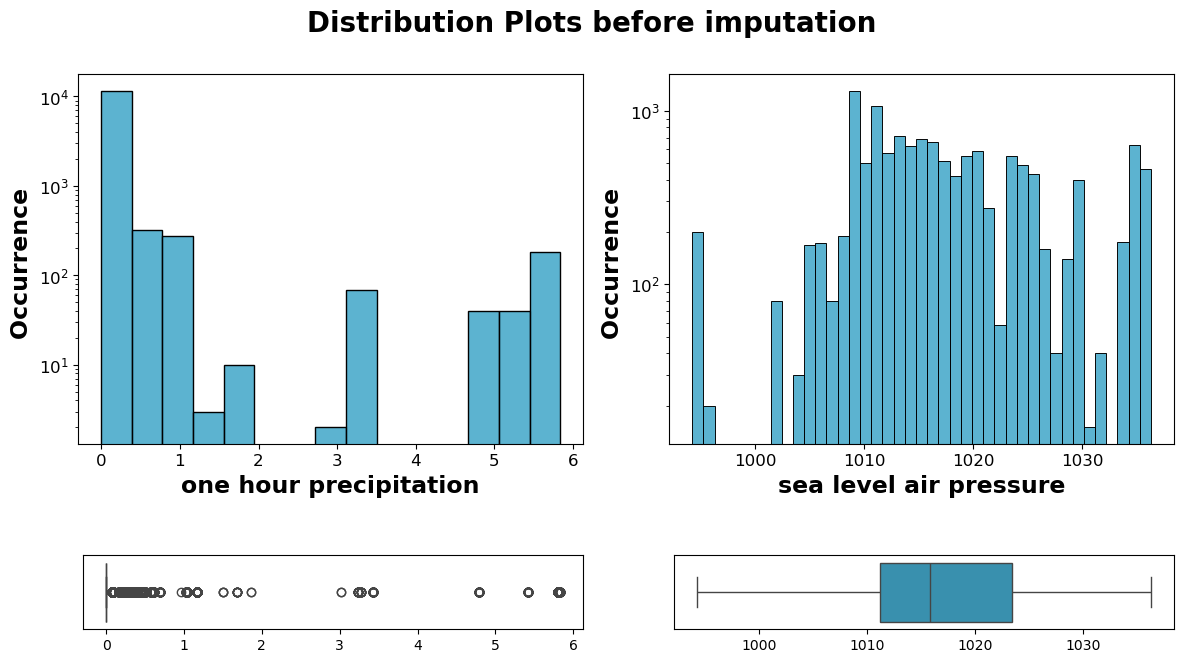

In [73]:
values_to_show = ["one hour precipitation", "sea level air pressure"]
distribution_plot(df=raw_data_analysis, parameters=values_to_show, columns_per_row=2, log_cutoff=100,figsize=(12,8),title = "Distribution Plots before imputation",)

In [74]:
def missing_percent_and_points(df:pd.DataFrame, mssing_threshold:int):
  missing_percentage: pd.Series = df.isnull().sum().sort_values(ascending=False)*100/len(df)
  missing_points: pd.Series = df.isnull().sum().sort_values(ascending=False)  # mask on dataframe for missing points?

  list_param: list[str] = missing_percentage.index.to_list()
  missed_values_percent: list[float] = missing_percentage.to_list()

  missed_points_values: list = missing_points.to_list()

  mis_df = pd.DataFrame({
    "Parameters": list_param,
    "missed_Percentage": missed_values_percent,
    "missing_Points": missed_points_values
     })
  mis_df= mis_df[mis_df['missed_Percentage']<=mssing_threshold]
  mis_df['availability_Percentage'] = 100 - mis_df['missed_Percentage']

  return mis_df



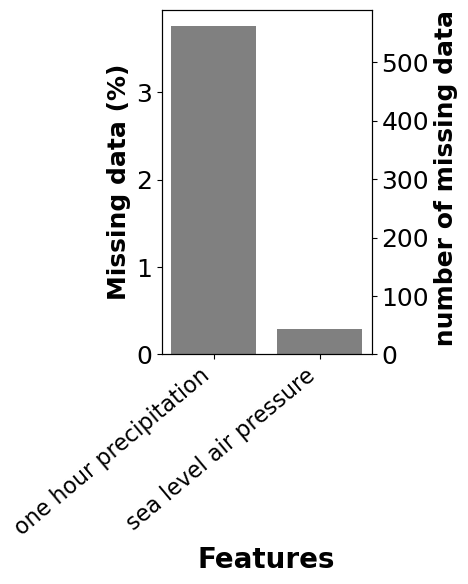

In [76]:
def number_percent_missing_data(
    data: pd.DataFrame,
    features_column: str,
    x_label: str,
    left_y_label: str,
    left_data: str,
    right_y_label: str,
    right_data: str,
    title: str,
    fontsize: int = 16,
):
    fig, ax1 = plt.subplots(figsize=(4.5, 6))

    df = data[(data[left_data] > 0) | (data[right_data] > 0)]


    ax1.bar(df[features_column], df[left_data], color="gray")

    ax1.set_xlabel(x_label, fontsize=fontsize+4)
    ax1.set_ylabel(left_y_label, fontsize=fontsize+2)
    # ax1.set_title(title, fontsize=fontsize)

    ax1.tick_params(axis="x", labelsize=fontsize)
    ax1.tick_params(axis="y", labelsize=fontsize+2)
    ax1.set_xticklabels(df[features_column], rotation=40, ha="right")

    ax2 = ax1.twinx()
    ax2.set_ylabel(right_y_label, fontsize=fontsize+2)
    ax2.tick_params(axis="y", labelsize=fontsize+2)
    ax2.set_ylim(0, df[right_data].max() + 100)

    plt.tight_layout()
    plt.show()


df_miss_under80 = missing_percent_and_points(raw_data_analysis, mssing_threshold=80)
number_percent_missing_data(data=df_miss_under80,
                            features_column="Parameters",
                            x_label='Features',
                            left_y_label='Missing data (%)',
                            left_data='missed_Percentage',
                            right_y_label=' number of missing data',
                            right_data="missing_Points",
                            title="")

In [77]:
df_miss_under80

,Parameters,missed_Percentage,missing_Points,availability_Percentage
0,one hour precipitation,3.750575,489,96.249425
1,sea level air pressure,0.291456,38,99.708544
2,Unnamed: 0,0.000000,0,100.000000
3,point_location,0.000000,0,100.000000
4,scan V direction,0.000000,0,100.000000
5,spot ID,0.000000,0,100.000000
6,scan ID,0.000000,0,100.000000
7,path,0.000000,0,100.000000
8,substrate ID,0.000000,0,100.000000
9,datetime,0.000000,0,100.000000


## Impute one hour precipitation and sea level air pressure

In [ ]:
raw_grouped_dataset_to_mapped_for_analysis = raw_data_analysis.copy()

In [ ]:
from sklearn.impute import KNNImputer
knn_imputer_uniform = KNNImputer(weights="uniform")
knn_imputer_dist=KNNImputer(weights="distance")


In [ ]:
raw_grouped_dataset_to_mapped_for_analysis[["one hour precipitation imputed knn dist", "sea level air pressure imputed knn dist"]] = knn_imputer_dist.fit_transform(raw_grouped_dataset_to_mapped_for_analysis[["one hour precipitation", "sea level air pressure"]])
raw_grouped_dataset_to_mapped_for_analysis[["one hour precipitation imputed knn uniform", "sea level air pressure imputed knn uniform"]] = knn_imputer_uniform.fit_transform(raw_grouped_dataset_to_mapped_for_analysis[["one hour precipitation", "sea level air pressure"]])

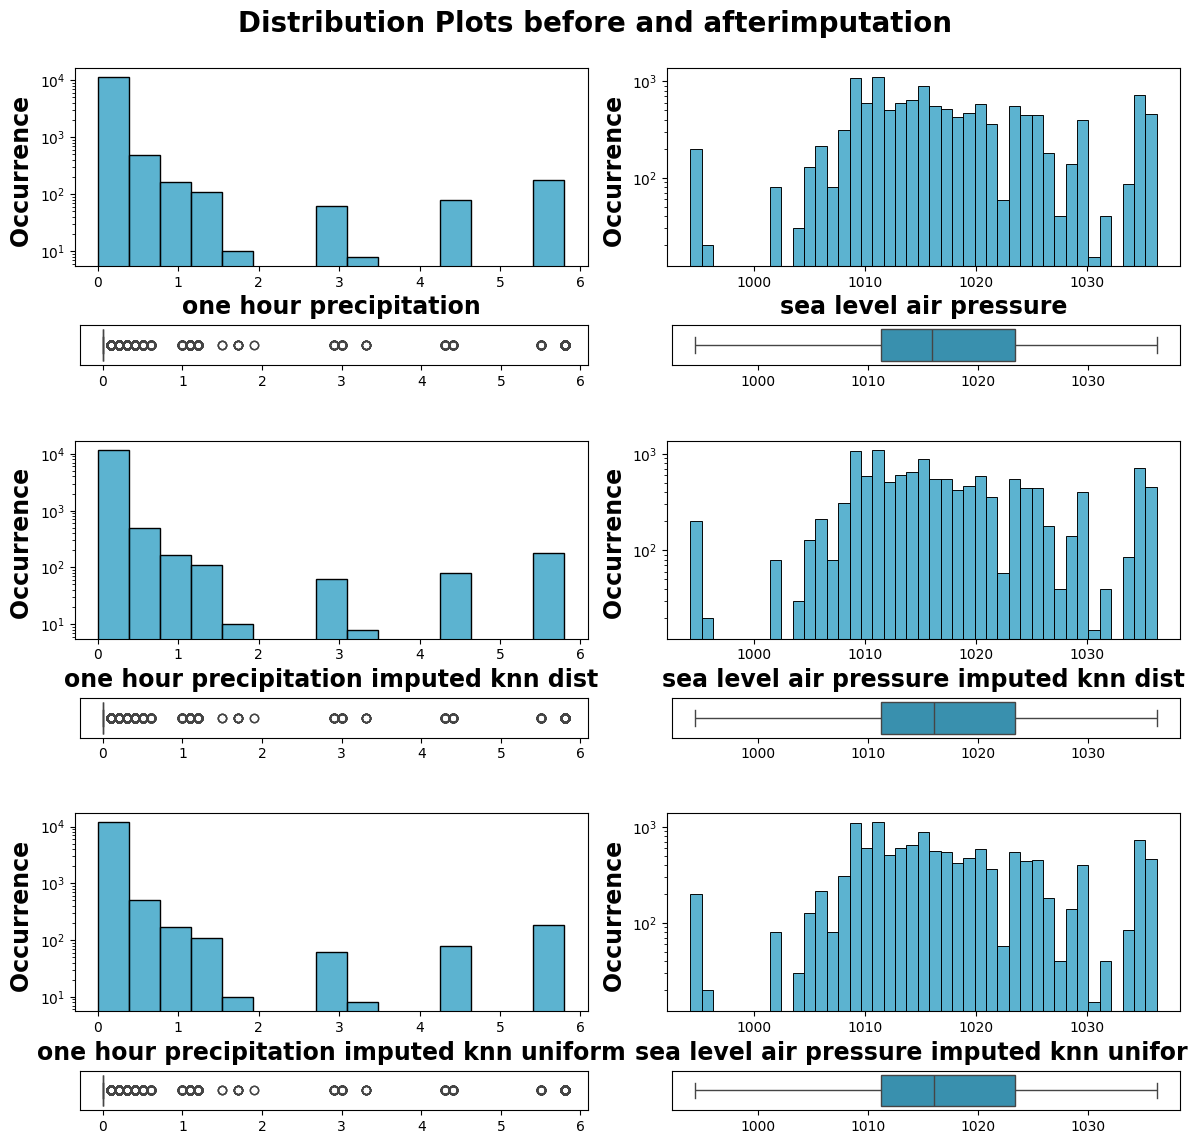

In [ ]:
values_to_show = ["one hour precipitation", "sea level air pressure", "one hour precipitation imputed knn dist", "sea level air pressure imputed knn dist","one hour precipitation imputed knn uniform", "sea level air pressure imputed knn uniform"]
distribution_plot(df=raw_grouped_dataset_to_mapped_for_analysis, parameters=values_to_show, columns_per_row=2, log_cutoff=100,figsize=(12,12),title = "Distribution Plots before and afterimputation")

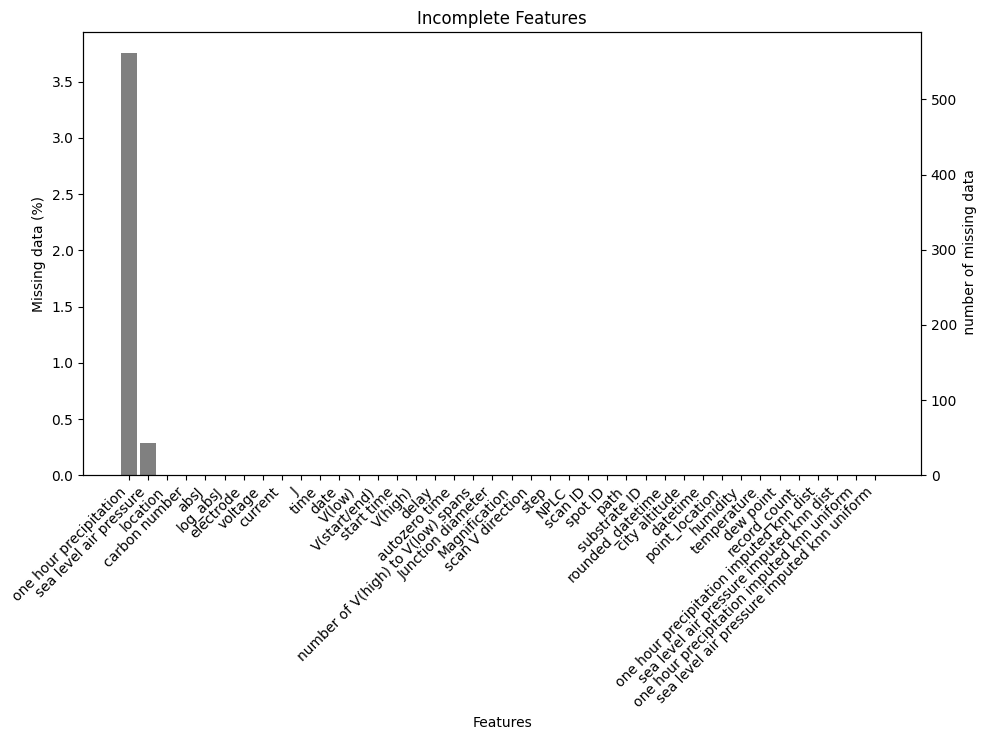

In [ ]:
df_miss_under80 = missing_percent_and_points(raw_grouped_dataset_to_mapped_for_analysis, mssing_threshold=80)
number_percent_missing_data(df=df_miss_under80,
                            features_column="Parameters",
                            x_label='Features',
                            left_y_label='Missing data (%)',
                            left_data='missed_Percentage',
                            right_y_label=' number of missing data',
                            right_data="missing_Points",
                            title="Incomplete Features")

In [ ]:
raw_data_analysis[["one hour precipitation", "sea level air pressure"]] = knn_imputer_dist.fit_transform(raw_data_analysis[["one hour precipitation", "sea level air pressure"]])

In [ ]:
# get water content
raw_data_analysis['water content from dew'] = raw_data_analysis.apply(
    lambda row: calculate_water_content_from_dew_point(
        row['city altitude'],
        row['dew point'],
        row['temperature'],
        row['sea level air pressure']
    ),
    axis=1
)

In [3]:
df_miss_under80 = missing_percent_and_points(raw_data_analysis, mssing_threshold=80)
number_percent_missing_data(data=df_miss_under80,
                            features_column="Parameters",
                            x_label='Features',
                            left_y_label='Missing data (%)',
                            left_data='missed_Percentage',
                            right_y_label=' number of missing data',
                            right_data="missing_Points",
                            title="Incomplete Features")

## export dataset

In [ ]:
raw_data_analysis.to_csv(data_folder/'cleand_dataset_filtered_by_carbon_number_dropped_tests_with_weather_imputed.csv',index=False)

In [2]:
# raw_data_analysis = raw_data_analysis[raw_data_analysis['scan V direction']!=0].reset_index(drop=True)
# raw_data_analysis[raw_data_analysis['scan V direction']==0]

In [1]:
# raw_data_analysis.columns

In [ ]:
# raw_grouped_dataset_to_mapped_scan_no_direct_dropped

In [ ]:
# raw_data_analysis.to_csv(data_folder/'new_cleaned_dataset_filtered_by_carbon_number_dropped_tests_dropped_random_v_direction_with_weather_imputed_V3.csv',index=False)

## scratches

In [ ]:
# from meteostat import Point, Hourly
# import pandas as pd

# def round_time(dt):
#     """Round time to the nearest hour."""
#     minutes = dt.minute
#     # If minutes are less than 30, round down to the nearest hour
#     if minutes < 30:
#         return dt.floor('H')  # Round down to the nearest hour
#     # If minutes are 30 or more, round up to the next hour
#     else:
#         return dt.ceil('H')   # Round up to the next hour

# # Example data for rounding the time
# raw_grouped_dataset_to_mapped = pd.DataFrame({
#     'datetime': [pd.Timestamp('2017-02-20 21:07:00')]
# })

# # Apply the custom rounding function to the 'datetime' column
# raw_grouped_dataset_to_mapped['rounded_datetime'] = raw_grouped_dataset_to_mapped['datetime'].apply(round_time)

# # Fetch weather data for the given location using weighted average and 50 km radius
# def fetch_weather_data(location, rounded_dt):
#     """Fetch weighted temperature and humidity for the given location and datetime."""
#     # Set up the Point location with weighted interpolation and a 50 km radius
#     location.method = 'weighted'  # Use weighted interpolation
#     location.radius = 28000  # Set radius to 50 km
#     # location.max_count = 10  # Use up to 4 stations for interpolation

#     # Define the start and end time for fetching data (using rounded datetime)
#     start_time = rounded_dt
#     end_time = rounded_dt

#     # Fetch hourly data for the location point
#     daily_data = Hourly(location, start=start_time, end=end_time)
#     daily_data = daily_data.fetch()

#     # Check if data is available and return the values
#     if not daily_data.empty:
#         temp = daily_data['temp']  # Take the weighted average of temperature
#         rh = daily_data['rhum']  # Take the weighted average of humidity
#         records_number = daily_data.shape[0]  # Number of records retrieved
#         return temp, rh, records_number
#     else:
#         return None, None, None  # Return None if no data is available

# # Example usage
# location = Point(42.377307408348535, -71.1159339051407)  # Ames, Iowa with an altitude of 320 m
# Time = pd.Timestamp('2017-02-20 21:07:00')

# # Round the datetime and fetch weather data
# rounded_time = round_time(Time)
# temp, rh, records_number = fetch_weather_data(location, rounded_time)

# print(f"Temperature: {temp}°C, Humidity: {rh}%, Number of records: {records_number}")

Temperature: time
2017-02-20 21:00:00    5.9
Freq: h, Name: temp, dtype: float64°C, Humidity: time
2017-02-20 21:00:00    32.1
Freq: h, Name: rhum, dtype: float64%, Number of records: 1


In [ ]:
# from meteostat import Stations
# # 42.02905566250881, -93.64854182679626
# # Define the latitude and longitude
# lat = 42.02905566250881
# lon = -93.64854182679626

# # Create a query to find stations near the given location within a 20 km radius
# stations = Stations().nearby(lat, lon, 28000)  # Radius in meters (20 km)

# # Fetch the station data as a DataFrame
# stations_df = stations.fetch()

# # Get the number of stations found
# number_of_stations = len(stations_df)

# # Output the result
# print(f"Number of weather stations within 20 km: {number_of_stations}")


Number of weather stations within 20 km: 2


In [ ]:
# from meteostat import Point
# # 42.377307408348535, -71.1159339051407
# # Define location with latitude, longitude, and altitude
# lat = 42.02905566250881     # Example latitude for San Francisco
# lon = -93.64854182679626  # Example longitude for San Francisco

# # Create a Point object
# location = Point(lat=lat, lon=lon)

# # Additional attributes for customization
# location.method = 'weighted'        # Interpolation method: 'weighted' or 'nearest'
# location.radius = 30000             # Search radius in meters


# # Example usage to get station data or weather data
# # For example, retrieving weather data might look something like this
# from meteostat import Daily
# from datetime import datetime

# # Set the time period
# end = datetime(2018, 12, 31, 23, 00)
# start = datetime(2018, 12, 31, 23, 00)


# # Round the datetime and fetch weather data

# # Get daily weather data for the location
# data = Hourly(location, start, end)
# data = data.fetch()

# # Display the weather data
# print(data)


                     temp  dwpt  rhum  prcp  snow   wdir  wspd  wpgt    pres  \
time                                                                           
2018-12-31 23:00:00  -0.4  -1.5  93.0   0.0   NaN  340.0  24.1   NaN  1010.8   

                     tsun  coco  
time                             
2018-12-31 23:00:00   NaN   NaN  


In [ ]:
# print(location.radius)

30000


In [ ]:
# stations = Stations().nearby(lat, lon, location.radius)
# stations = stations.fetch()
# print('number of stations:',len(stations))
# # Initialize a dictionary to hold data from each station
# station_data = {}
# stations
# # Loop through each station and retrieve daily data for the time period
# # for station_id in stations.index:
# #     # Get daily weather data for the station
# #     data = Hourly(station_id, start, end)
# #     data = data.fetch()

# #     # Store the data in the dictionary
# #     station_data[station_id] = data

# # # Display data for each station
# # for station_id, data in station_data.items():
# #     print(f"Station ID: {station_id}")
# #     print(data)
# #     print("\n" + "-" * 40 + "\n")

number of stations: 2


,name,country,region,wmo,icao,latitude,longitude,elevation,timezone,hourly_start,hourly_end,daily_start,daily_end,monthly_start,monthly_end,distance
id,,,,,,,,,,,,,,,,
KAMW0,Ames / Old Orchard Mobile Home Park,US,IA,<NA>,KAMW,41.9921,-93.6218,291.0,America/Chicago,2006-01-01,2024-10-06,2006-01-01,2022-04-24,2006-01-01,2022-01-01,4665.588282
KBNW0,Boone,US,IA,<NA>,KBNW,42.0496,-93.8476,354.0,America/Chicago,2006-01-01,2024-10-06,2006-01-01,2022-04-24,2011-01-01,2022-01-01,16596.755397


In [ ]:
working_data = raw_grouped_dataset_to_mapped.copy()

In [ ]:
def is_single_test(file_path):
    sub_name = file_path.split('\\')[-2]
    return sub_name

working_data['substrate ID']=working_data['path'].apply(is_single_test)

In [ ]:
# working_data.to_csv(data_folder/'cleand_dataset_filtered_by_carbon_number_dropped_tests_with_weather.csv',index=False)